# HCP fingerprinting analysis

This notebook evaluates cross-day individual identification using precomputed RSI.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import Parallel, delayed
from scipy.spatial.distance import cdist




project_root = Path('../..').resolve()
rsi_dir = project_root / "results/rsi/HCP/single_run"
info_dir = project_root / "data/HCP/info"
n_target = 100
n_jobs = 16

### Load precomputed RSI features

Each run contains 10-bin RSI values. The bins are flattened into one feature vector per subject before session-level aggregation.


In [2]:
run_paths = [rsi_dir / ("run%d_test_multibin_rsi.npy" % run) for run in range(1, 5)]
missing = [str(path) for path in run_paths if not path.is_file()]
if missing:
    raise FileNotFoundError("Missing precomputed RSI file(s): %s" % ", ".join(missing))

runs = [np.load(path) for path in run_paths]
runs = [run.reshape(run.shape[0], -1) for run in runs]

if len({run.shape[0] for run in runs}) != 1:
    raise ValueError("All runs must contain the same subjects")
if len({run.shape[1] for run in runs}) != 1:
    raise ValueError("All runs must contain the same flattened feature dimension")

print("Loaded run shapes:", [run.shape for run in runs])


Loaded run shapes: [(708, 73400), (708, 73400), (708, 73400), (708, 73400)]


### Fingerprinting calculation

For each source/target session pair, every source subject is matched to the target subject with the highest Pearson correlation.


In [3]:
def _compute_single_pair(source_index, target_index, source_features, target_features):
    """Return identification accuracy for one source/target pair."""
    n_subjects = source_features.shape[0]
    if source_index == target_index:
        return source_index, target_index, 1.0, n_subjects

    # scipy's correlation distance is 1 - Pearson correlation.
    distances = cdist(source_features, target_features, metric="correlation")
    predicted = np.argmin(distances, axis=1)
    correct = int(np.sum(predicted == np.arange(n_subjects)))
    return source_index, target_index, correct / float(n_subjects), correct


def calculate_pairwise_fingerprinting(session_features, n_jobs=n_jobs):
    """Calculate the cross-session identification accuracy matrix."""
    n_sessions = len(session_features)
    n_subjects = session_features[0].shape[0]
    results = Parallel(n_jobs=n_jobs, prefer="threads")([
        delayed(_compute_single_pair)(i, j, session_features[i], session_features[j])
        for i in range(n_sessions)
        for j in range(n_sessions)
    ])

    accuracy = np.zeros((n_sessions, n_sessions), dtype=float)
    for i, j, acc, correct in results:
        accuracy[i, j] = acc
        if i != j:
            print("Session %d -> Session %d: %d/%d (%.2f%%)" %
                  (i + 1, j + 1, correct, n_subjects, 100 * acc))
    return accuracy


### Select 100 unrelated test subjects with minimal head motion.

The HCP metadata is kept under `data/HCP/info` so this notebook is self-contained within the project. Within each family, the participant with the lowest four-run mean framewise displacement is retained.


In [4]:
hcp_metadata = pd.read_csv(info_dir / "hcp_998.csv")
train_ids = pd.read_csv(info_dir / "train.txt", header=None)[0].astype(int).tolist()
test_ids = pd.read_csv(info_dir / "test.txt", header=None)[0].astype(int).tolist()


def get_low_motion_unrelated_indices(metadata, subject_ids, n_select=n_target):
    """Return indices of the lowest-motion unrelated subjects."""
    test_df = pd.DataFrame({
        "Subject": subject_ids,
        "original_idx": np.arange(len(subject_ids)),
    })
    columns = ["Subject", "FD_mean_4run", "Mother_ID_x", "Father_ID_x"]
    merged = test_df.merge(metadata[columns], on="Subject", how="inner")
    if merged.empty:
        raise ValueError("No test subjects matched hcp_998.csv")

    # Missing parent IDs identify unrelated singletons, not one shared family.
    merged["Mother_ID_x"] = merged["Mother_ID_x"].fillna(merged["Subject"].astype(str) + "_M")
    merged["Father_ID_x"] = merged["Father_ID_x"].fillna(merged["Subject"].astype(str) + "_F")
    merged["family_id"] = (merged["Mother_ID_x"].astype(str) + "_" +
                               merged["Father_ID_x"].astype(str))

    unrelated = (merged.sort_values("FD_mean_4run")
                       .drop_duplicates("family_id", keep="first"))
    selected = unrelated.head(n_select)
    indices = selected["original_idx"].astype(int).tolist()

    print("Matched test subjects: %d/%d" % (len(merged), len(subject_ids)))
    print("Unrelated subjects available: %d" % len(unrelated))
    print("Selected subjects: %d" % len(indices))
    if len(indices) < n_select:
        print("Warning: fewer than %d unrelated subjects are available." % n_select)
    return indices


target_indices = get_low_motion_unrelated_indices(hcp_metadata, test_ids)
target_subjects = [test_ids[index] for index in target_indices]


Matched test subjects: 708/708
Unrelated subjects available: 341
Selected subjects: 100


### Aggregate runs and calculate accuracy

In [5]:
session_features = [
    (runs[0] + runs[1])[target_indices],
    (runs[2] + runs[3])[target_indices],
]

# Z-score each feature across the selected subjects within each session.
def zscore_columns(data, epsilon=1e-10):
    mean = data.mean(axis=0)
    std = data.std(axis=0, ddof=1)
    return (data - mean) / (std + epsilon)

session_features = [zscore_columns(session) for session in session_features]
accuracy_matrix = calculate_pairwise_fingerprinting(session_features, n_jobs=n_jobs)
accuracy_matrix


Session 1 -> Session 2: 98/100 (98.00%)
Session 2 -> Session 1: 99/100 (99.00%)


array([[1.  , 0.98],
       [0.99, 1.  ]])

### Display the fingerprinting matrix

Font set: Whitney


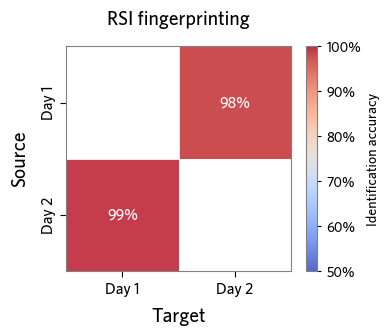

(<Figure size 400x380 with 2 Axes>,
 <Axes: title={'center': 'RSI fingerprinting'}, xlabel='Target', ylabel='Source'>)

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
from mpl_toolkits.axes_grid1 import make_axes_locatable

font_path = project_root / 'font/Whitney-Medium.otf'

fm.fontManager.addfont(str(font_path))
prop = fm.FontProperties(fname=str(font_path))
font_name = prop.get_name()

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['svg.fonttype'] = 'none'
print(f"Font set: {font_name}")


def plot_fingerprinting_heatmap(
    acc_matrix,
    title='Fingerprinting accuracy matrix',
    x_label='Target',
    y_label='Source',
    cmap="coolwarm",
    figsize=(4, 3.8),
    vmin=None,
    vmax=None,
):
    """
    绘制跨 Run 指纹识别准确率的热力图，使用百分制显示。
    输入 acc_matrix 仍然是 0-1 的准确率。
    """

    # 1. 数据预处理：转成百分制
    plot_matrix = acc_matrix.astype(float).copy() * 100
    np.fill_diagonal(plot_matrix, np.nan)
    num_runs = plot_matrix.shape[0]
    run_order = [f"Day {i+1}" for i in range(num_runs)]

    # vmin/vmax 也从 0-1 转成百分制
    vmin_pct = None if vmin is None else vmin * 100
    vmax_pct = None if vmax is None else vmax * 100

    # 2. 创建画布
    fig, ax = plt.subplots(figsize=figsize)

    # 3. 绘制热力图
    sns.heatmap(
        plot_matrix,
        ax=ax,
        alpha=0.85,
        annot=True,
        fmt=".0f",
        cmap=cmap,
        square=True,
        vmin=vmin_pct,
        vmax=vmax_pct,
        linewidths=.5,
        mask=np.isnan(plot_matrix),
        cbar=False,
        annot_kws={"size": 11}
    )

    # 给每个 annotation 加上 %
    for text in ax.texts:
        text.set_text(text.get_text() + "%")

    # 3.5 Colorbar
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.15)

    cbar = fig.colorbar(ax.collections[0], cax=cax)
    cbar.set_label('Identification accuracy')

    # Colorbar 刻度显示 %
    ticks = cbar.get_ticks()
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([f"{tick:.0f}%" for tick in ticks])

    # 4. 坐标轴与标签美化
    ax.set_title(title, fontsize=14, pad=16)
    ax.set_xlabel(x_label, fontsize=14, labelpad=8)
    ax.set_ylabel(y_label, fontsize=14, labelpad=9)

    ax.set_xticklabels(run_order, rotation=0)
    ax.set_yticklabels(run_order, rotation=90, va='center')

    ax.tick_params(axis='both', which='major', labelsize=11)

    # 5. 边框设置
    fig_border_color = 'gray'
    fig_border_width = 0.8

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color(fig_border_color)
        spine.set_linewidth(fig_border_width)

    ax.tick_params(direction='out', length=4, width=fig_border_width)

    cbar.outline.set_edgecolor(fig_border_color)
    cbar.outline.set_linewidth(fig_border_width)
    cax.tick_params(direction='out', length=3, width=fig_border_width)

    # 6. 布局优化并直接显示
    plt.tight_layout()
    plt.show()

    return fig, ax


plot_fingerprinting_heatmap(
    accuracy_matrix,
    title='RSI fingerprinting',
    vmin=0.5,
    vmax=1,
)
